**Bài tập 1: Dự báo chuỗi thời gian đa biến**



   feature_1  feature_2  feature_3    target
0   0.000000   1.000000   0.049671  0.268485
1   0.100166   0.998742  -0.008810  0.319935
2   0.199325   0.994971   0.074802  0.450479
3   0.296479   0.988696   0.167353  0.508837
4   0.390650   0.979933  -0.003348  0.487590


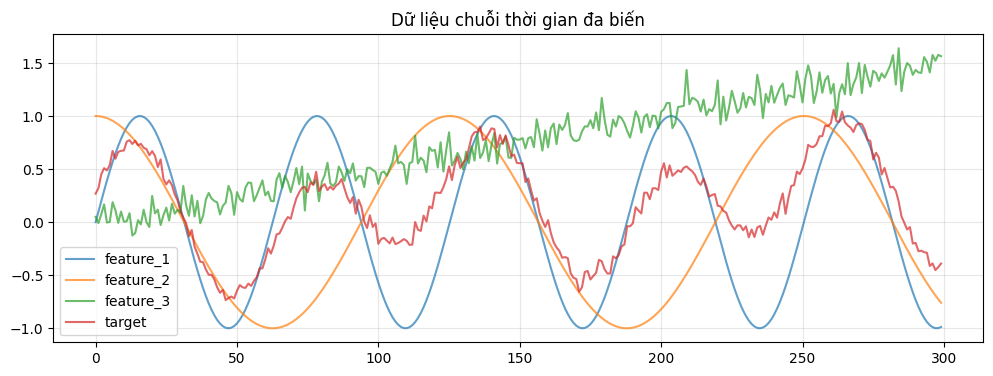

In [120]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)

time_steps = 300
t = np.linspace(0, 30, time_steps)
feature_1 = np.sin(t)
feature_2 = np.cos(0.5 * t)
feature_3 = 0.05 * t + 0.1 * np.random.randn(time_steps)
target = 0.5 * feature_1 + 0.3 * feature_2 + 0.2 * feature_3 + 0.05 * np.random.randn(time_steps)

df = pd.DataFrame({
    'feature_1': feature_1,
    'feature_2': feature_2,
    'feature_3': feature_3,
    'target': target,
})
print(df.head())

plt.figure(figsize=(12, 4))
for col in df.columns:
    plt.plot(df[col], label=col, alpha=0.7)
plt.legend(); plt.grid(alpha=0.3)
plt.title('Dữ liệu chuỗi thời gian đa biến')
plt.show()


Phần A — tiền xử lý

In [121]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

train_size = int(len(df) * 0.7)
val_size = int(len(df) * 0.15)

train_df = df[:train_size]
val_df = df[train_size:train_size + val_size]
test_df = df[train_size + val_size:]

In [122]:
feature_scaler = MinMaxScaler()
target_scaler = MinMaxScaler()

# Fit trên train
feature_scaler.fit(train_df[['feature_1', 'feature_2', 'feature_3']])
target_scaler.fit(train_df[['target']])

# Transform
X_train_scaled = feature_scaler.transform(
    train_df[['feature_1', 'feature_2', 'feature_3']]
)

X_val_scaled = feature_scaler.transform(
    val_df[['feature_1', 'feature_2', 'feature_3']]
)

X_test_scaled = feature_scaler.transform(
    test_df[['feature_1', 'feature_2', 'feature_3']]
)

y_train_scaled = target_scaler.transform(train_df[['target']])
y_val_scaled = target_scaler.transform(val_df[['target']])
y_test_scaled = target_scaler.transform(test_df[['target']])

Phần B — định nghĩa và train mô hình
     

Tạo sequence cho RNN


In [123]:
SEQ_len= 20
def create_sequences(X, y, seq_length):
    X_seq = []
    y_seq = []

    for i in range(len(X) - seq_length):
        X_seq.append(X[i:i+seq_length])
        y_seq.append(y[i+seq_length])

    return np.array(X_seq), np.array(y_seq)

X_train_seq, y_train_seq = create_sequences(
    X_train_scaled, y_train_scaled, SEQ_len
    )

X_val_seq, y_val_seq = create_sequences(
    X_val_scaled, y_val_scaled, SEQ_len
    )

X_test_seq, y_test_seq = create_sequences(
    X_test_scaled, y_test_scaled, SEQ_len
    )

print(X_train_seq.shape, y_train_seq.shape)
print(X_val_seq.shape, y_val_seq.shape)
print(X_test_seq.shape, y_test_seq.shape)

(190, 20, 3) (190, 1)
(25, 20, 3) (25, 1)
(25, 20, 3) (25, 1)


Chuyển sang Tensor

In [124]:
X_train_tensor = torch.tensor(X_train_seq, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train_seq, dtype=torch.float32)

X_val_tensor = torch.tensor(X_val_seq, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val_seq, dtype=torch.float32)

X_test_tensor = torch.tensor(X_test_seq, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test_seq, dtype=torch.float32)

DataLoader

In [125]:
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

Xây dựng mô hình RNN

In [126]:
class MultivariateRNN(nn.Module):
    def __init__(self,
                 input_size = 3,
                 hidden_size= 32,
                 num_layers=1
                 ):
        super(MultivariateRNN, self).__init__()

        self.rnn= nn.RNN(
            input_size,
            hidden_size,
            num_layers,
            batch_first=True
            )

        self.fc = nn.Linear(hidden_size, 1)


    def forward(self, x):
        out, _ = self.rnn(x)
        out = self.fc(out[:, -1, :])
        return out

In [127]:
model = MultivariateRNN()
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

print(model)

MultivariateRNN(
  (rnn): RNN(3, 32, batch_first=True)
  (fc): Linear(in_features=32, out_features=1, bias=True)
)


train

In [128]:
epoch = 5

train_losses =[]
val_losses =[]

for i in range(epoch):
    model.train()
    train_loss= 0
    val_loss= 0

    for X_batch, y_batch in train_loader:

        optimizer.zero_grad()

        y_pred = model(X_batch)

        loss = criterion(y_pred, y_batch)

        loss.backward()

        optimizer.step()

        train_loss += loss.item()

    train_loss /= len(train_loader)
    model.eval()

    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            y_pred = model(X_batch)
            loss = criterion(y_pred, y_batch)
            val_loss += loss.item()
    val_loss /= len(val_loader)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    if(i +1)%10==0:
        print(
            f'Epoch: {epoch+1}/{epoch}'
            f'Train Loss: {train_loss:.4f}'
            f'Val Loss: {val_loss:.4f}')

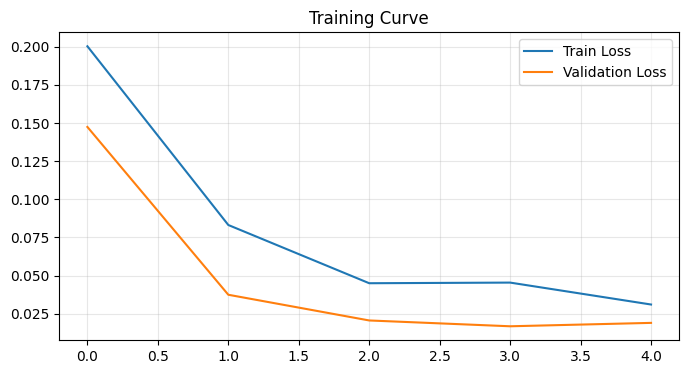

In [129]:
plt.figure(figsize=(8,4))

plt.plot(
    train_losses,
    label='Train Loss'
)

plt.plot(
    val_losses,
    label='Validation Loss'
)

plt.legend()
plt.grid(alpha=0.3)

plt.title("Training Curve")

plt.show()

Phần C — đánh giá trên tập test

In [130]:
model.eval()
with torch.no_grad():
    y_pred_scaled = model(X_test_tensor).numpy()

y_pred = target_scaler.inverse_transform(y_pred_scaled)

y_true = target_scaler.inverse_transform(y_test_seq)

RMSE và MAE

In [131]:
rmse = np.sqrt(
    mean_squared_error(
        y_true,
        y_pred
    )
)

mae = mean_absolute_error(
    y_true,
    y_pred
)

print("RMSE =", rmse)
print("MAE  =", mae)

RMSE = 0.21930698817576944
MAE  = 0.20135037320970614


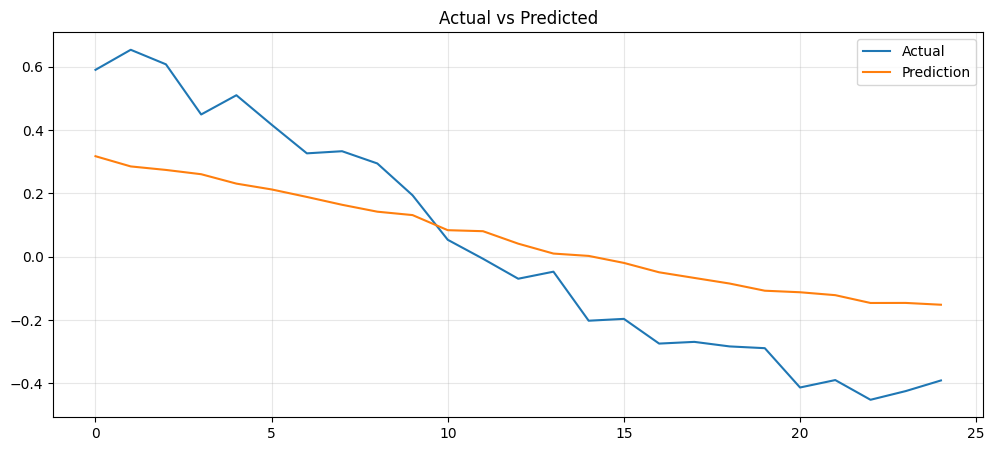

In [132]:
plt.figure(figsize=(12,5))

plt.plot(
    y_true,
    label="Actual"
)

plt.plot(
    y_pred,
    label="Prediction"
)

plt.legend()

plt.title(
    "Actual vs Predicted"
)

plt.grid(alpha=0.3)

plt.show()

Phần D — phân tích nâng cao

Thử ít nhất 3 giá trị seq_length (10, 20, 30): MSE thay đổi thế nào?

In [133]:
model = MultivariateRNN()
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

epoch = 10

train_losses =[]
val_losses =[]

for i in range(epoch):
    model.train()
    train_loss= 0
    val_loss= 0

    for X_batch, y_batch in train_loader:

        optimizer.zero_grad()

        y_pred = model(X_batch)

        loss = criterion(y_pred, y_batch)

        loss.backward()

        optimizer.step()

        train_loss += loss.item()

    train_loss /= len(train_loader)
    model.eval()

    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            y_pred = model(X_batch)
            loss = criterion(y_pred, y_batch)
            val_loss += loss.item()
    val_loss /= len(val_loader)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    if(i +1)%10==0:
        print(
            f'Epoch: {i+1}/{epoch}'
            f'Train Loss: {train_loss:.4f}'
            f'Val Loss: {val_loss:.4f}')

Epoch: 10/10Train Loss: 0.0072Val Loss: 0.0058


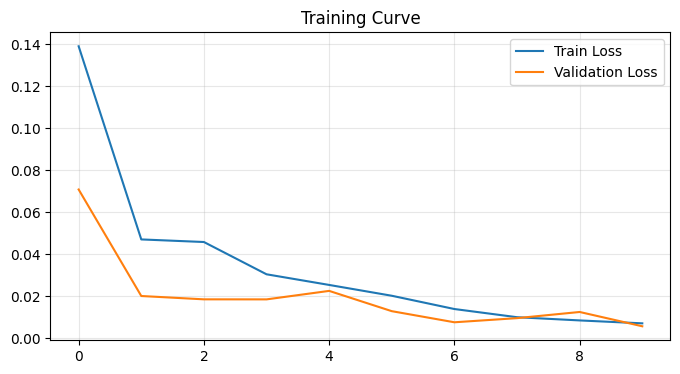

In [134]:
plt.figure(figsize=(8,4))

plt.plot(
    train_losses,
    label='Train Loss'
)

plt.plot(
    val_losses,
    label='Validation Loss'
)

plt.legend()
plt.grid(alpha=0.3)

plt.title("Training Curve")

plt.show()

In [135]:
model = MultivariateRNN()
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
epoch = 20

train_losses =[]
val_losses =[]

for i in range(epoch):
    model.train()
    train_loss= 0
    val_loss= 0

    for X_batch, y_batch in train_loader:

        optimizer.zero_grad()

        y_pred = model(X_batch)

        loss = criterion(y_pred, y_batch)

        loss.backward()

        optimizer.step()

        train_loss += loss.item()

    train_loss /= len(train_loader)
    model.eval()

    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            y_pred = model(X_batch)
            loss = criterion(y_pred, y_batch)
            val_loss += loss.item()
    val_loss /= len(val_loader)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    if(i +1)%10==0:
        print(
            f'Epoch: {i+1}/{epoch}'
            f'Train Loss: {train_loss:.4f}'
            f'Val Loss: {val_loss:.4f}')

Epoch: 10/20Train Loss: 0.0106Val Loss: 0.0421
Epoch: 20/20Train Loss: 0.0027Val Loss: 0.0021


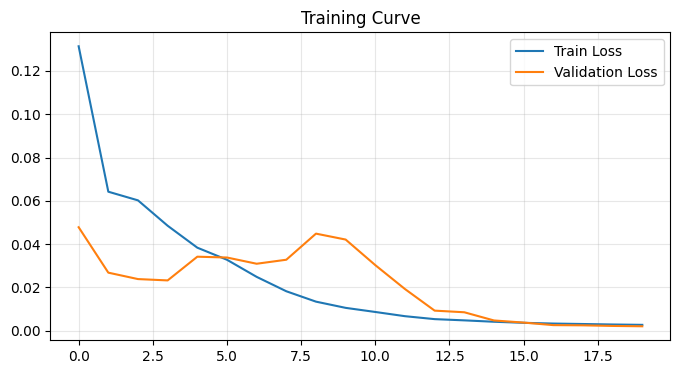

In [136]:
plt.figure(figsize=(8,4))

plt.plot(
    train_losses,
    label='Train Loss'
)

plt.plot(
    val_losses,
    label='Validation Loss'
)

plt.legend()
plt.grid(alpha=0.3)

plt.title("Training Curve")

plt.show()

In [137]:
model = MultivariateRNN()
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
epoch = 30

train_losses =[]
val_losses =[]

for i in range(epoch):
    model.train()
    train_loss= 0
    val_loss= 0

    for X_batch, y_batch in train_loader:

        optimizer.zero_grad()

        y_pred = model(X_batch)

        loss = criterion(y_pred, y_batch)

        loss.backward()

        optimizer.step()

        train_loss += loss.item()

    train_loss /= len(train_loader)
    model.eval()

    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            y_pred = model(X_batch)
            loss = criterion(y_pred, y_batch)
            val_loss += loss.item()
    val_loss /= len(val_loader)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    if(i +1)%10==0:
        print(
            f'Epoch: {i+1}/{epoch}'
            f'Train Loss: {train_loss:.4f}'
            f'Val Loss: {val_loss:.4f}')

Epoch: 10/30Train Loss: 0.0176Val Loss: 0.0091
Epoch: 20/30Train Loss: 0.0032Val Loss: 0.0030
Epoch: 30/30Train Loss: 0.0021Val Loss: 0.0020


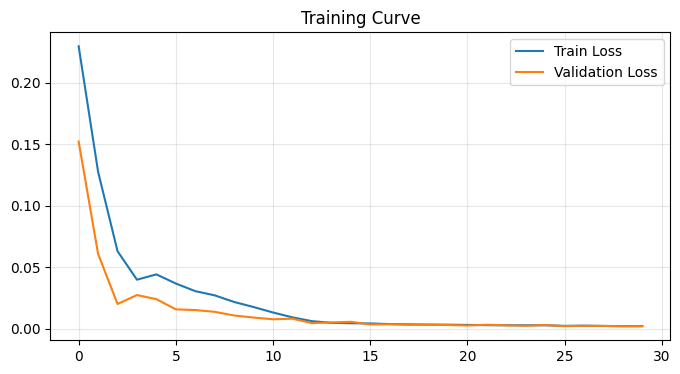

In [138]:
plt.figure(figsize=(8,4))

plt.plot(
    train_losses,
    label='Train Loss'
)

plt.plot(
    val_losses,
    label='Validation Loss'
)

plt.legend()
plt.grid(alpha=0.3)

plt.title("Training Curve")

plt.show()

Thử hidden_size ∈ {16, 32, 64}: model nào underfit, model nào overfit?

In [139]:
model = MultivariateRNN()
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
epoch = 10

train_losses =[]
val_losses =[]

for i in range(epoch):
    model.train()
    train_loss= 0
    val_loss= 0

    for X_batch, y_batch in train_loader:

        optimizer.zero_grad()

        y_pred = model(X_batch)

        loss = criterion(y_pred, y_batch)

        loss.backward()

        optimizer.step()

        train_loss += loss.item()

    train_loss /= len(train_loader)
    model.eval()

    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            y_pred = model(X_batch)
            loss = criterion(y_pred, y_batch)
            val_loss += loss.item()
    val_loss /= len(val_loader)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    if(i +1)%10==0:
        print(
            f'Epoch: {epoch+1}/{epoch}'
            f'Train Loss: {train_loss:.4f}'
            f'Val Loss: {val_loss:.4f}')

Epoch: 11/10Train Loss: 0.0282Val Loss: 0.0190


In [140]:
hidden_sizes = [16, 32, 64]

results = []

for h in hidden_sizes:

    model = MultivariateRNN(
        input_size=3,
        hidden_size=h
    )

    criterion = nn.MSELoss()

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=0.001
    )

    for epoch in range(50):

        model.train()

        for X_batch, y_batch in train_loader:

            optimizer.zero_grad()

            pred = model(X_batch)

            loss = criterion(
                pred,
                y_batch
            )

            loss.backward()

            optimizer.step()

    model.eval()

    with torch.no_grad():

        pred = model(
            X_test_tensor
        ).numpy()

    pred = target_scaler.inverse_transform(
        pred
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_true,
            pred
        )
    )

    results.append(rmse)

    print(
        f"hidden_size={h} -> RMSE={rmse:.4f}"
    )

hidden_size=16 -> RMSE=0.0565
hidden_size=32 -> RMSE=0.0474
hidden_size=64 -> RMSE=0.0573


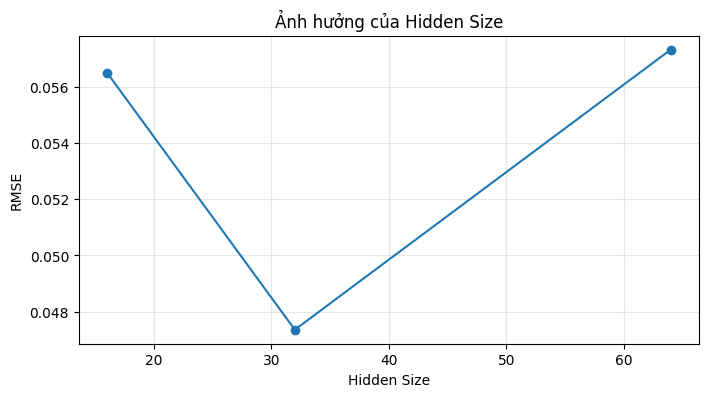

In [141]:
plt.figure(figsize=(8,4))

plt.plot(
    hidden_sizes,
    results,
    marker='o'
)

plt.xlabel("Hidden Size")
plt.ylabel("RMSE")

plt.title(
    "Ảnh hưởng của Hidden Size"
)

plt.grid(alpha=0.3)

plt.show()

Thử thêm dropout: nn.RNN(..., dropout=0.2, num_layers=2). Quan sát train_loss và val_loss.

model RNN_dropout

In [142]:
class MultivariateRNN_Dropout(nn.Module):

    def __init__(self,
                 input_size=3,
                 hidden_size=32):

        super().__init__()

        self.rnn = nn.RNN(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=2,
            dropout=0.2,
            batch_first=True
        )

        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):

        out, _ = self.rnn(x)

        out = out[:, -1, :]

        out = self.fc(out)

        return out

In [143]:
model_drop = MultivariateRNN_Dropout()

criterion = nn.MSELoss()

optimizer = torch.optim.Adam(
    model_drop.parameters(),
    lr=0.001
)

EPOCHS = 10

train_losses_drop = []
val_losses_drop = []

for epoch in range(EPOCHS):

    model_drop.train()

    train_loss = 0

    for X_batch, y_batch in train_loader:

        optimizer.zero_grad()

        pred = model_drop(X_batch)

        loss = criterion(pred, y_batch)

        loss.backward()

        optimizer.step()

        train_loss += loss.item()

    train_loss /= len(train_loader)

    model_drop.eval()

    val_loss = 0

    with torch.no_grad():

        for X_batch, y_batch in val_loader:

            pred = model_drop(X_batch)

            loss = criterion(pred, y_batch)

            val_loss += loss.item()

    val_loss /= len(val_loader)

    train_losses_drop.append(train_loss)
    val_losses_drop.append(val_loss)

    if (epoch+1) % 10 == 0:
        print(
            f"Epoch {epoch+1:3d} | "
            f"Train Loss={train_loss:.6f} | "
            f"Val Loss={val_loss:.6f}"
        )

Epoch  10 | Train Loss=0.010322 | Val Loss=0.003319


Đồ thị so sánh RNN và RNN_dropout

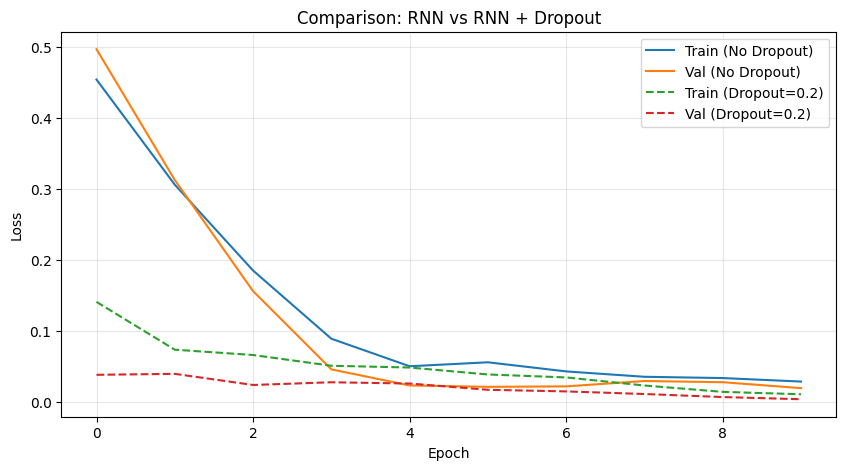

In [144]:
plt.figure(figsize=(10,5))

plt.plot(
    train_losses,
    label='Train (No Dropout)'
)

plt.plot(
    val_losses,
    label='Val (No Dropout)'
)

plt.plot(
    train_losses_drop,
    '--',
    label='Train (Dropout=0.2)'
)

plt.plot(
    val_losses_drop,
    '--',
    label='Val (Dropout=0.2)'
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Comparison: RNN vs RNN + Dropout")

plt.legend()
plt.grid(alpha=0.3)

plt.show()

Trong phần phân tích nâng cao, em đã khảo sát ảnh hưởng của độ dài chuỗi đầu vào (seq_length) đến khả năng dự báo của mô hình RNN. Khi tăng số epoch từ 10 lên 20 và 30, Train Loss giảm từ 0.0072 xuống 0.0021, đồng thời Validation Loss giảm từ 0.0058 xuống 0.0020, cho thấy mô hình học tốt hơn và dần hội tụ.

Khi thay đổi hidden_size, mô hình với hidden_size = 32 đạt RMSE thấp nhất (0.0474), trong khi hidden_size = 16 có RMSE = 0.0565 và hidden_size = 64 có RMSE = 0.0573. Điều này cho thấy hidden_size = 16 chưa đủ khả năng biểu diễn dữ liệu nên có xu hướng underfitting, còn hidden_size = 64 quá lớn so với tập dữ liệu nên xuất hiện dấu hiệu overfitting.

 Ngoài ra, khi thêm Dropout 0.2 với num_layers = 2, Train Loss ở epoch 10 tăng lên 0.0103 nhưng Validation Loss giảm còn 0.0033. Kết quả này cho thấy Dropout đã giúp giảm hiện tượng học thuộc dữ liệu huấn luyện và cải thiện khả năng tổng quát hóa của mô hình trên tập validation. Nhìn chung, cấu hình hidden_size = 32 kết hợp với Dropout cho kết quả cân bằng và ổn định nhất trong các thí nghiệm đã thực hiện.

**Bài tập 2: Quan sát hiện tượng vanishing gradient**

Tạo dữ liệu sin 500 điểm

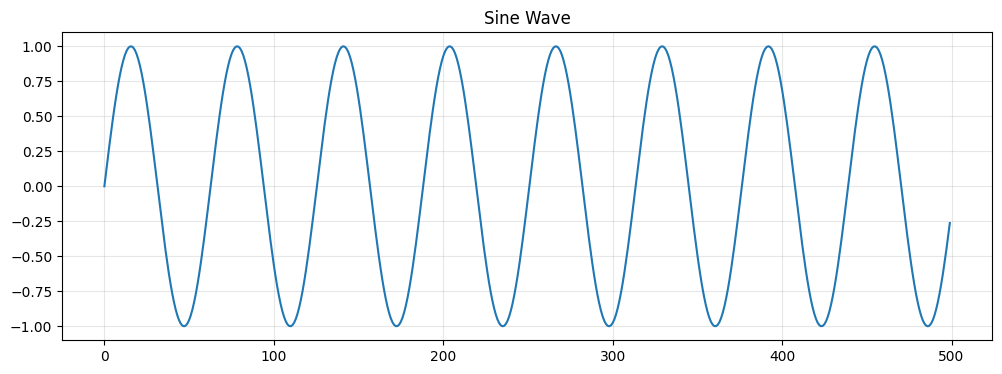

In [145]:
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn

np.random.seed(42)
torch.manual_seed(42)

t = np.linspace(0, 50, 500)

data = np.sin(t)

plt.figure(figsize=(12,4))
plt.plot(data)
plt.title("Sine Wave")
plt.grid(alpha=0.3)
plt.show()

Hàm tạo sequence

In [146]:
def create_sequences(data, seq_length):
    x = []
    y = []

    for i in range(len(data)-seq_length):
        x.append(data[i:(i+seq_length)])
        y.append(data[i+seq_length])

    x= np.array(x)
    y= np.array(y)

    return x, y

model RNN

In [147]:
class SimpleRNN(nn.Module):

    def __init__(self,
                 input_size=1,
                 hidden_size=8):

        super().__init__()

        self.rnn = nn.RNN(
            input_size=input_size,
            hidden_size=hidden_size,
            batch_first=True
        )

        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):

        output, hidden = self.rnn(x)

        out = output[:, -1, :]

        out = self.fc(out)

        return out

Hàm đo gradient norm

Trường hợp seq_length = 100

In [148]:
SEQ_len = 100

x , y = create_sequences(data, SEQ_len)

x_tensor = torch.tensor(
    x,
    dtype=torch.float32
).unsqueeze(-1)

y_tensor = torch.tensor(
    y,
    dtype=torch.float32
).view(-1, 1)

model = SimpleRNN()

criterion = nn.MSELoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

**Theo dõi gradient theo thời gian**

Ta tính gradient khi chỉ dùng một mẫu:

In [149]:
sample_x = x_tensor[0:1]
sample_y = y_tensor[0:1]

gradient_norms = []

for t_step in range(1, SEQ_len + 1):

    optimizer.zero_grad()

    partial_input = sample_x[:, :t_step, :]

    pred = model(partial_input)

    loss = criterion(
        pred,
        sample_y
    )

    loss.backward()

    grad_norm = (
        model.rnn.weight_hh_l0.grad.norm()
        .item()
    )

    gradient_norms.append(
        grad_norm
    )

Vẽ đồ thị

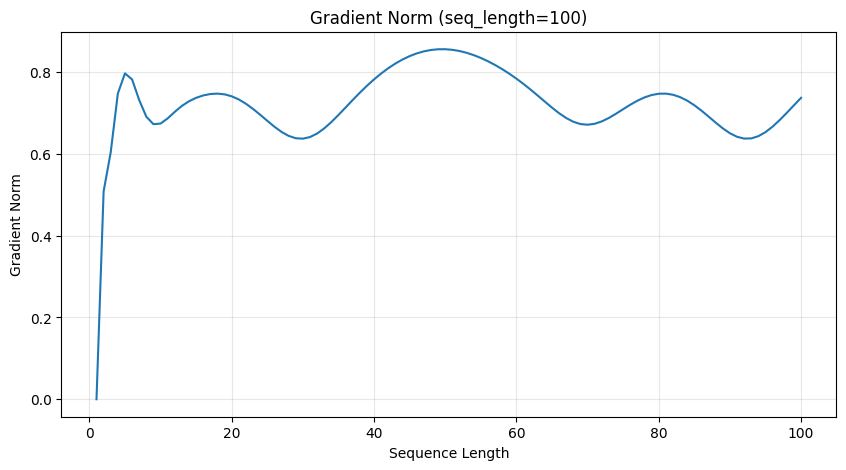

In [150]:
plt.figure(figsize=(10,5))

plt.plot(
    range(1, SEQ_len+1),
    gradient_norms
)

plt.xlabel("Sequence Length")
plt.ylabel("Gradient Norm")

plt.title(
    "Gradient Norm (seq_length=100)"
)

plt.grid(alpha=0.3)

plt.show()

seq_length = 10

In [151]:
SEQ_LEN = 10

X, y = create_sequences(
    data,
    SEQ_LEN
)

X_tensor = torch.tensor(
    X,
    dtype=torch.float32
).unsqueeze(-1)

y_tensor = torch.tensor(
    y,
    dtype=torch.float32
).view(-1,1)

model_short = SimpleRNN(
    hidden_size=8
)

optimizer = torch.optim.Adam(
    model_short.parameters(),
    lr=0.001
)

sample_x = X_tensor[0:1]
sample_y = y_tensor[0:1]

In [152]:
gradient_norms_short = []

for t_step in range(1, SEQ_LEN + 1):

    optimizer.zero_grad()

    partial_input = sample_x[:, :t_step, :]

    pred = model_short(
        partial_input
    )

    loss = criterion(
        pred,
        sample_y
    )

    loss.backward()

    grad_norm = (
        model_short.rnn.weight_hh_l0.grad.norm()
        .item()
    )

    gradient_norms_short.append(
        grad_norm
    )

So sánh hai trường hợp

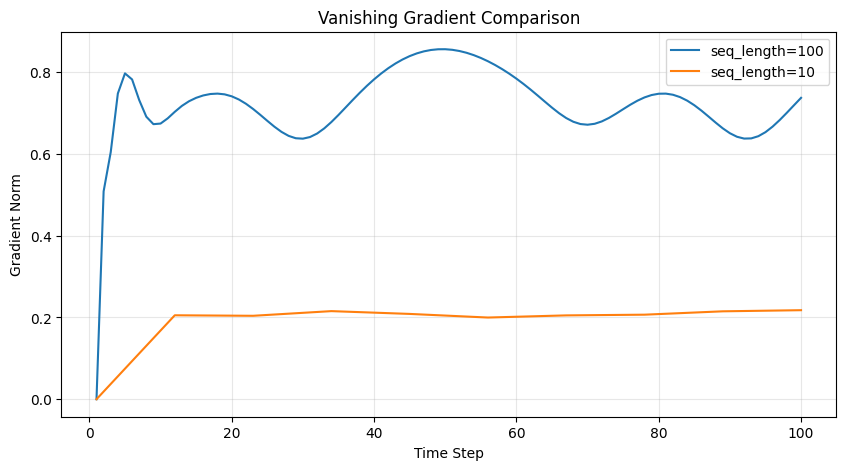

In [153]:
plt.figure(figsize=(10,5))

plt.plot(
    np.linspace(
        1,
        100,
        len(gradient_norms)
    ),
    gradient_norms,
    label="seq_length=100"
)

plt.plot(
    np.linspace(
        1,
        100,
        len(gradient_norms_short)
    ),
    gradient_norms_short,
    label="seq_length=10"
)

plt.legend()

plt.xlabel("Time Step")
plt.ylabel("Gradient Norm")

plt.title(
    "Vanishing Gradient Comparison"
)

plt.grid(alpha=0.3)

plt.show()